In [1]:
from leakly import SimulationConfig, simulate_dataset

simulated = simulate_dataset(
    SimulationConfig(
        n_samples=2000,
        n_features=1000,
        n_covariates=3,
        effect_fraction=0.05,
        effect_size=0.05,
        class_balance=0.1,
        random_state=42,
    )
)
X, y, covariates = simulated.X, simulated.y, simulated.covariates

In [2]:
from leakly import load_example_leakage_config, load_example_nonleakage_config
from leakly import print_config

leakage_config = load_example_leakage_config()
nonleakage_config = load_example_nonleakage_config()


<Axes: title={'center': 'histogram'}, xlabel='Test set score', ylabel='Count'>

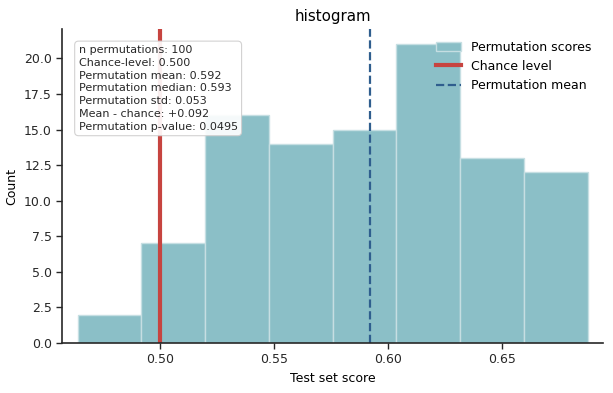

In [3]:
from leakly import MLPipeline, permute_label, SummaryPlotter

test_AUCs = []
for i in range(100):
    permuted_y = permute_label(y, random_state=i)
    pipeline = MLPipeline(
        X,
        permuted_y,
        covariates=covariates,
        config=leakage_config,
    )
    pipeline.fit()
    auc = pipeline.evaluate(metric="auc")
    test_AUCs.append(auc)

# plot distribution of test AUCs
plotter = SummaryPlotter(test_scores=test_AUCs, 
                         chance_level=0.5)
plotter.plot()



In [ ]:
print(plotter.permutation_pvalue())

In [ ]:
test_AUCs = []
for i in range(1000):
    permuted_y = permute_label(y, random_state=i)
    pipeline = MLPipeline(
        X,
        permuted_y,
        covariates=covariates,
        config=nonleakage_config,
    )
    pipeline.fit()
    auc = pipeline.evaluate(metric="auc")
    test_AUCs.append(auc)

# plot distribution of test AUCs
plotter = SummaryPlotter(test_scores=test_AUCs)
plotter.plot()